<a href="https://colab.research.google.com/github/Dhiren05/new-demo/blob/main/wood_timber_bibliometric_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌲 Computer Vision, ML & DL for Wood and Timber Products
## Scopus-Based Bibliometric & Systematic Mapping Review (1983–2026)

**Reference**: Goycochea Casas et al. (2026). *Computer Vision, Machine Learning, and Deep Learning for Wood and Timber Products: A Scopus-Based Bibliometric and Systematic Mapping Review (1983–2026, Early Access)*. *Forests*.

---

This notebook implements the **complete analytical pipeline** described in the paper:

| Step | Section | Description |
|------|---------|-------------|
| 1 | §2.3 | Data Ingestion & Text Preprocessing |
| 2 | §2.4 | Rule-Based Application Classification (9 categories) |
| 3 | §2.5 | Hierarchical Methodological Classification (DL / ML / CV) |
| 4 | §2.6.1 | Validation Metrics (Accuracy, Precision, Recall, F1) |
| 5 | §3 & §5 | Bibliometric Visualizations |

---
## 1. Environment Setup & Dependencies

Install and import all required packages. All libraries listed here are available by default on Google Colab; the `pip install` cell is included for completeness and reproducibility.

In [1]:
# [CELL 1] — Install dependencies (safe to re-run)
!pip install -q pandas numpy matplotlib seaborn scikit-learn networkx scipy

In [2]:
# [CELL 2] — Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter, defaultdict
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    precision_recall_fscore_support,
    confusion_matrix,
)
import networkx as nx
from scipy import stats
import warnings
import textwrap
import re

warnings.filterwarnings("ignore")

# ── Global plot style ──────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.facecolor": "white",
})

# Reproducible colour palette (9 application categories)
APP_PALETTE = {
    "SurfaceQC":     "#2ecc71",
    "I3D":           "#3498db",
    "SpeciesID":     "#e74c3c",
    "PBP":           "#9b59b6",
    "LRP":           "#f39c12",
    "SawmillAuto":   "#1abc9c",
    "Microstructure":"#e67e22",
    "WPP":           "#34495e",
    "Dimensional":   "#95a5a6",
}

METHOD_PALETTE = {
    "Deep Learning":          "#2980b9",
    "Classical ML":           "#27ae60",
    "Classical CV":           "#c0392b",
}

print("✅ All libraries loaded successfully.")

✅ All libraries loaded successfully.


---
## 2. Data Ingestion & Text Preprocessing (Section 2.3)

We construct a **synthetic Scopus-like dataset** with realistic metadata fields (`Title`, `Abstract`, `Author Keywords`, `Index Keywords`, `Year`, `Citations`, `Document Type`, `Country`). Each record is designed to exercise the classification rules from the paper.

> **To use real data**: Replace the sample DataFrame below with `pd.read_csv('scopus_export.csv')` from your own Scopus export.

In [3]:
# [CELL 3] — Synthetic Scopus-like dataset

sample_records = [
    # ── SurfaceQC papers ──────────────────────────────────────────────
    {
        "Title": "Automated surface defect detection in hardwood lumber using deep learning",
        "Abstract": "This study presents a CNN-based system for detecting knots, cracks, and surface defects on lumber surfaces. A ResNet-50 backbone was fine-tuned on annotated images of planed wood boards, achieving high grading accuracy.",
        "Author Keywords": "surface defect; cnn; wood grading; lumber inspection",
        "Index Keywords": "defect detection; deep learning; quality control; hardwood",
        "Year": 2022, "Citations": 34, "Document Type": "Article", "Country": "Finland",
        "GT_Application": "SurfaceQC", "GT_Method": "Deep Learning"
    },
    {
        "Title": "Machine vision system for online veneer surface quality inspection",
        "Abstract": "A real-time machine vision pipeline was developed for detecting checks, splits, and roughness on veneer sheets. Classical image processing including edge detection and morphological operations was employed for surface quality grading.",
        "Author Keywords": "veneer; surface quality; machine vision; edge detection",
        "Index Keywords": "quality control; wood surface; image processing",
        "Year": 2010, "Citations": 52, "Document Type": "Article", "Country": "Germany",
        "GT_Application": "SurfaceQC", "GT_Method": "Classical CV"
    },
    {
        "Title": "SVM-based lumber grading through surface texture analysis",
        "Abstract": "Support vector machines were trained on GLCM texture features extracted from grayscale images of sawn timber surfaces for automated grading.",
        "Author Keywords": "svm; texture; lumber grading; glcm",
        "Index Keywords": "support vector machine; wood surface; classification",
        "Year": 2016, "Citations": 28, "Document Type": "Article", "Country": "Canada",
        "GT_Application": "SurfaceQC", "GT_Method": "Classical ML"
    },
    # ── I3D papers ────────────────────────────────────────────────────
    {
        "Title": "3D reconstruction of internal log structure using CT scanning and deep learning",
        "Abstract": "Computed tomography images of Norway spruce logs were segmented using a 3D U-Net to reconstruct internal knot geometry and heartwood boundaries for sawing optimization.",
        "Author Keywords": "ct scanning; 3d reconstruction; u-net; internal structure",
        "Index Keywords": "computed tomography; deep learning; knot detection; log scanning",
        "Year": 2023, "Citations": 12, "Document Type": "Article", "Country": "Sweden",
        "GT_Application": "I3D", "GT_Method": "Deep Learning"
    },
    {
        "Title": "X-ray imaging for non-destructive evaluation of wood internal defects",
        "Abstract": "X-ray radiography combined with classical image processing techniques was used to detect internal voids, knots, and decay within sawn timber without cutting.",
        "Author Keywords": "x-ray; non-destructive testing; internal defect; wood",
        "Index Keywords": "radiography; ndt; wood inspection",
        "Year": 2005, "Citations": 65, "Document Type": "Article", "Country": "Japan",
        "GT_Application": "I3D", "GT_Method": "Classical CV"
    },
    # ── SpeciesID papers ──────────────────────────────────────────────
    {
        "Title": "Tropical wood species identification from macroscopic images using a fine-tuned EfficientNet",
        "Abstract": "An EfficientNet-B4 model was trained on a dataset of cross-section images of 50 tropical hardwood species for automated species recognition to combat illegal logging.",
        "Author Keywords": "wood species identification; efficientnet; tropical timber; illegal logging",
        "Index Keywords": "species recognition; deep learning; timber identification",
        "Year": 2024, "Citations": 8, "Document Type": "Article", "Country": "Brazil",
        "GT_Application": "SpeciesID", "GT_Method": "Deep Learning"
    },
    {
        "Title": "Random forest classification of wood species using NIR spectral features",
        "Abstract": "Near-infrared spectroscopy data combined with random forest classifiers were used to distinguish among 20 commercial timber species.",
        "Author Keywords": "random forest; nir; wood species; spectroscopy",
        "Index Keywords": "near-infrared; species classification; machine learning",
        "Year": 2019, "Citations": 41, "Document Type": "Article", "Country": "Malaysia",
        "GT_Application": "SpeciesID", "GT_Method": "Classical ML"
    },
    # ── PBP papers ────────────────────────────────────────────────────
    {
        "Title": "Deep learning-based quality prediction for MDF production lines",
        "Abstract": "A convolutional neural network was deployed on the MDF panel production line to predict internal bond strength and surface quality of medium density fiberboard panels.",
        "Author Keywords": "mdf; panel production; cnn; quality prediction",
        "Index Keywords": "medium density fiberboard; deep learning; production line",
        "Year": 2023, "Citations": 6, "Document Type": "Article", "Country": "China",
        "GT_Application": "PBP", "GT_Method": "Deep Learning"
    },
    {
        "Title": "Statistical process control for plywood veneer lay-up using SVM",
        "Abstract": "Support vector machines were applied to monitor veneer lay-up orientation in plywood panel manufacturing, reducing misalignment defects.",
        "Author Keywords": "plywood; svm; manufacturing; veneer lay-up",
        "Index Keywords": "panel production; statistical process control; support vector machine",
        "Year": 2017, "Citations": 19, "Document Type": "Article", "Country": "Turkey",
        "GT_Application": "PBP", "GT_Method": "Classical ML"
    },
    # ── LRP papers ────────────────────────────────────────────────────
    {
        "Title": "YOLO-based log-end detection for automated roundwood scaling",
        "Abstract": "A YOLOv5 object detection model was trained to identify and measure log ends for automated volume estimation in log yards.",
        "Author Keywords": "yolo; log detection; roundwood; volume estimation",
        "Index Keywords": "object detection; deep learning; log scaling; log yard",
        "Year": 2024, "Citations": 3, "Document Type": "Conference Paper", "Country": "Austria",
        "GT_Application": "LRP", "GT_Method": "Deep Learning"
    },
    {
        "Title": "Automated bucking optimization using laser scanning and threshold segmentation",
        "Abstract": "A classical computer vision pipeline using laser profile scanning and adaptive thresholding was used to optimize bucking decisions for roundwood stems.",
        "Author Keywords": "bucking; laser scanning; roundwood; optimization",
        "Index Keywords": "log processing; segmentation; laser scanner",
        "Year": 2008, "Citations": 44, "Document Type": "Article", "Country": "Norway",
        "GT_Application": "LRP", "GT_Method": "Classical CV"
    },
    # ── SawmillAuto papers ────────────────────────────────────────────
    {
        "Title": "Robotic sawing guided by deep learning-based log scanning",
        "Abstract": "A sawmill automation system combining robotic arm control with a CNN-based log scanner for optimal sawing pattern determination was developed.",
        "Author Keywords": "sawmill; robotics; cnn; log scanning; automation",
        "Index Keywords": "sawmill automation; robot; deep learning; sawing optimization",
        "Year": 2025, "Citations": 1, "Document Type": "Article", "Country": "Finland",
        "GT_Application": "SawmillAuto", "GT_Method": "Deep Learning"
    },
    {
        "Title": "Decision tree-based sawing strategy selection in small-diameter log processing",
        "Abstract": "Decision tree classifiers were used to select the optimal sawing pattern for small-diameter logs based on geometric and grade features in a sawmill environment.",
        "Author Keywords": "decision tree; sawing pattern; sawmill; small-diameter log",
        "Index Keywords": "machine learning; sawmill; wood processing",
        "Year": 2014, "Citations": 31, "Document Type": "Article", "Country": "Canada",
        "GT_Application": "SawmillAuto", "GT_Method": "Classical ML"
    },
    # ── Microstructure papers ──────────────────────────────────────────
    {
        "Title": "Semantic segmentation of wood cell structures using U-Net on microscopy images",
        "Abstract": "Brightfield microscopy images of thin sections of wood were segmented using a U-Net architecture to quantify vessel density, fiber wall thickness, and ray parenchyma fraction.",
        "Author Keywords": "u-net; microscopy; wood anatomy; cell segmentation",
        "Index Keywords": "semantic segmentation; deep learning; microstructure; wood cell",
        "Year": 2022, "Citations": 15, "Document Type": "Article", "Country": "Switzerland",
        "GT_Application": "Microstructure", "GT_Method": "Deep Learning"
    },
    {
        "Title": "Characterization of annual ring boundaries using classical image analysis",
        "Abstract": "Classical image processing including Otsu thresholding and morphological filtering was applied to cross-sectional microscopy images to delineate annual ring boundaries for dendrochronology.",
        "Author Keywords": "annual ring; dendrochronology; image analysis; thresholding",
        "Index Keywords": "microscopy; wood anatomy; ring boundary; classical image processing",
        "Year": 2001, "Citations": 78, "Document Type": "Article", "Country": "USA",
        "GT_Application": "Microstructure", "GT_Method": "Classical CV"
    },
    # ── WPP papers ────────────────────────────────────────────────────
    {
        "Title": "Predicting modulus of elasticity of timber using CNN on grain pattern images",
        "Abstract": "A convolutional neural network was trained to predict the modulus of elasticity (MOE) and modulus of rupture (MOR) of sawn timber boards from grain pattern images, enabling non-destructive strength grading.",
        "Author Keywords": "moe; mor; cnn; strength grading; grain pattern",
        "Index Keywords": "modulus of elasticity; deep learning; wood property prediction",
        "Year": 2023, "Citations": 9, "Document Type": "Article", "Country": "Germany",
        "GT_Application": "WPP", "GT_Method": "Deep Learning"
    },
    {
        "Title": "Moisture content estimation using random forest regression on NIR spectra",
        "Abstract": "Random forest regression models were used to estimate wood moisture content from near-infrared spectroscopy data in a kiln drying process.",
        "Author Keywords": "moisture content; random forest; nir; kiln drying",
        "Index Keywords": "wood property; regression; near-infrared; machine learning",
        "Year": 2020, "Citations": 23, "Document Type": "Article", "Country": "Chile",
        "GT_Application": "WPP", "GT_Method": "Classical ML"
    },
    # ── Dimensional papers ────────────────────────────────────────────
    {
        "Title": "Stereo vision-based board dimension measurement in sawmill environments",
        "Abstract": "A stereo camera system with classical calibration and triangulation was used for real-time measurement of board width, thickness, and warp in a sawmill production line.",
        "Author Keywords": "stereo vision; dimension measurement; board geometry; sawmill",
        "Index Keywords": "3d measurement; stereo camera; wood geometry",
        "Year": 2012, "Citations": 37, "Document Type": "Article", "Country": "Sweden",
        "GT_Application": "Dimensional", "GT_Method": "Classical CV"
    },
    {
        "Title": "Deep learning for real-time log diameter estimation from drone imagery",
        "Abstract": "A Mask R-CNN model was used to segment individual log cross-sections from drone-captured images of log piles for automated diameter estimation and volume calculation.",
        "Author Keywords": "mask r-cnn; drone; log diameter; volume estimation",
        "Index Keywords": "instance segmentation; deep learning; measurement; uav",
        "Year": 2024, "Citations": 5, "Document Type": "Article", "Country": "Brazil",
        "GT_Application": "Dimensional", "GT_Method": "Deep Learning"
    },
    # ── Additional papers to enrich the dataset ───────────────────────
    {
        "Title": "Transfer learning with VGG-16 for automated veneer defect classification",
        "Abstract": "VGG-16 pretrained on ImageNet was fine-tuned for classifying veneer sheet defects including knots, mineral streaks, and bark pockets on a production line.",
        "Author Keywords": "vgg; transfer learning; veneer defect; classification",
        "Index Keywords": "deep learning; defect detection; wood surface",
        "Year": 2021, "Citations": 27, "Document Type": "Article", "Country": "Finland",
        "GT_Application": "SurfaceQC", "GT_Method": "Deep Learning"
    },
    {
        "Title": "GAN-based data augmentation for rare wood defect categories",
        "Abstract": "A generative adversarial network was employed to synthesize training images for underrepresented wood surface defect categories, improving CNN classifier performance on imbalanced datasets.",
        "Author Keywords": "gan; data augmentation; wood defect; class imbalance",
        "Index Keywords": "generative adversarial network; surface quality; deep learning",
        "Year": 2023, "Citations": 11, "Document Type": "Article", "Country": "China",
        "GT_Application": "SurfaceQC", "GT_Method": "Deep Learning"
    },
    {
        "Title": "Transformer-based multi-label classification for sawmill log defects",
        "Abstract": "A vision transformer (ViT) was used to classify multiple concurrent defects in sawmill log scanning, outperforming CNN baselines.",
        "Author Keywords": "transformer; vision transformer; sawmill; multi-label; log defect",
        "Index Keywords": "deep learning; sawmill automation; defect detection",
        "Year": 2025, "Citations": 2, "Document Type": "Article", "Country": "Germany",
        "GT_Application": "SawmillAuto", "GT_Method": "Deep Learning"
    },
    {
        "Title": "K-nearest neighbour classification for wood species identification from texture descriptors",
        "Abstract": "K-NN classifiers operating on LBP and Gabor filter texture features were evaluated for distinguishing 15 temperate hardwood species from cross-section images.",
        "Author Keywords": "k-nn; texture; lbp; wood species",
        "Index Keywords": "species identification; pattern recognition; machine learning",
        "Year": 2015, "Citations": 55, "Document Type": "Article", "Country": "Poland",
        "GT_Application": "SpeciesID", "GT_Method": "Classical ML"
    },
    {
        "Title": "Density estimation of standing trees using terrestrial LiDAR point clouds and regression models",
        "Abstract": "Terrestrial laser scanning point clouds were processed with classical algorithms and combined with gradient boosting regression to estimate wood density of standing trees non-destructively.",
        "Author Keywords": "lidar; density; gradient boosting; non-destructive; standing tree",
        "Index Keywords": "terrestrial laser scanning; wood property; regression; point cloud",
        "Year": 2021, "Citations": 18, "Document Type": "Article", "Country": "France",
        "GT_Application": "WPP", "GT_Method": "Classical ML"
    },
    {
        "Title": "Particleboard thickness measurement using structured light and image processing",
        "Abstract": "A structured light system with classical triangulation and edge detection was deployed for inline thickness measurement of particleboard panels.",
        "Author Keywords": "structured light; particleboard; thickness measurement; inline",
        "Index Keywords": "panel production; measurement; image processing; quality control",
        "Year": 2009, "Citations": 33, "Document Type": "Article", "Country": "Italy",
        "GT_Application": "PBP", "GT_Method": "Classical CV"
    },
    {
        "Title": "Autoencoder-based anomaly detection for wood surface inspection",
        "Abstract": "A convolutional autoencoder was trained on defect-free wood surface images to detect anomalies indicating surface defects such as cracks and discoloration.",
        "Author Keywords": "autoencoder; anomaly detection; wood surface; unsupervised",
        "Index Keywords": "deep learning; surface inspection; anomaly",
        "Year": 2022, "Citations": 16, "Document Type": "Article", "Country": "South Korea",
        "GT_Application": "SurfaceQC", "GT_Method": "Deep Learning"
    },
    {
        "Title": "Logistic regression model for decay detection in utility poles using ultrasound features",
        "Abstract": "Logistic regression was used to classify the presence or absence of internal decay in wood utility poles based on ultrasound wave velocity features.",
        "Author Keywords": "logistic regression; decay; utility pole; ultrasound",
        "Index Keywords": "machine learning; non-destructive testing; wood decay",
        "Year": 2018, "Citations": 22, "Document Type": "Article", "Country": "USA",
        "GT_Application": "WPP", "GT_Method": "Classical ML"
    },
    {
        "Title": "Colour-based wood chip classification for pulp quality control",
        "Abstract": "A classical computer vision system using HSV colour space segmentation was developed to classify wood chips by bark content for pulp mill quality control.",
        "Author Keywords": "wood chip; colour; pulp; classification; hsv",
        "Index Keywords": "colour analysis; image processing; pulp mill; quality control",
        "Year": 1998, "Citations": 90, "Document Type": "Article", "Country": "Canada",
        "GT_Application": "SurfaceQC", "GT_Method": "Classical CV"
    },
    {
        "Title": "DenseNet for cross-sectional wood species recognition in forensic timber analysis",
        "Abstract": "DenseNet-121 was applied to microscopic cross-section images for forensic identification of illegally traded tropical timber species.",
        "Author Keywords": "densenet; forensic; species identification; tropical wood; microscopy",
        "Index Keywords": "deep learning; timber forensics; species recognition",
        "Year": 2024, "Citations": 4, "Document Type": "Article", "Country": "Indonesia",
        "GT_Application": "SpeciesID", "GT_Method": "Deep Learning"
    },
    {
        "Title": "Faster R-CNN for real-time knot detection in spruce log CT images",
        "Abstract": "Faster R-CNN was trained on annotated CT images of spruce logs to detect and localize internal knots for optimized sawing decisions.",
        "Author Keywords": "faster r-cnn; knot detection; ct; spruce; log",
        "Index Keywords": "object detection; computed tomography; deep learning; internal structure",
        "Year": 2023, "Citations": 7, "Document Type": "Article", "Country": "Finland",
        "GT_Application": "I3D", "GT_Method": "Deep Learning"
    },
]

df = pd.DataFrame(sample_records)
print(f"📊 Dataset loaded: {len(df)} records, {df['Year'].nunique()} unique years ({df['Year'].min()}–{df['Year'].max()})")
df[["Title", "Year", "Country", "GT_Application", "GT_Method"]].head(10)

📊 Dataset loaded: 30 records, 19 unique years (1998–2025)


,Title,Year,Country,GT_Application,GT_Method
0,Automated surface defect detection in hardwood...,2022,Finland,SurfaceQC,Deep Learning
1,Machine vision system for online veneer surfac...,2010,Germany,SurfaceQC,Classical CV
2,SVM-based lumber grading through surface textu...,2016,Canada,SurfaceQC,Classical ML
3,3D reconstruction of internal log structure us...,2023,Sweden,I3D,Deep Learning
4,X-ray imaging for non-destructive evaluation o...,2005,Japan,I3D,Classical CV
5,Tropical wood species identification from macr...,2024,Brazil,SpeciesID,Deep Learning
6,Random forest classification of wood species u...,2019,Malaysia,SpeciesID,Classical ML
7,Deep learning-based quality prediction for MDF...,2023,China,PBP,Deep Learning
8,Statistical process control for plywood veneer...,2017,Turkey,PBP,Classical ML
9,YOLO-based log-end detection for automated rou...,2024,Austria,LRP,Deep Learning


### 2.1 Text Preprocessing Function

Following Section 2.3 of the paper, we combine `Title`, `Abstract`, `Author Keywords`, and `Index Keywords` into a single lowercase string field (`combined_text`). This merged representation is used by both the application and methodological classifiers.

In [4]:
# [CELL 4] — Preprocessing: build combined_text field

def preprocess_text(row: pd.Series) -> str:
    """Combine Title, Abstract, Author Keywords, and Index Keywords into a
    single lowercase string for downstream keyword matching.

    Missing or NaN fields are gracefully handled as empty strings.
    """
    parts = [
        str(row.get("Title", "") or ""),
        str(row.get("Abstract", "") or ""),
        str(row.get("Author Keywords", "") or ""),
        str(row.get("Index Keywords", "") or ""),
    ]
    return " ".join(parts).lower().strip()


df["combined_text"] = df.apply(preprocess_text, axis=1)

# Quick sanity check
print("Preview of combined_text (first record, truncated to 200 chars):")
print(df["combined_text"].iloc[0][:200], "...")

Preview of combined_text (first record, truncated to 200 chars):
automated surface defect detection in hardwood lumber using deep learning this study presents a cnn-based system for detecting knots, cracks, and surface defects on lumber surfaces. a resnet-50 backbo ...


---
## 3. Rule-Based Application Classification (Section 2.4 & Pseudocode)

This implements the **weighted keyword scoring** system described in the paper's pseudocode:

- Each of the **9 application categories** has a curated keyword list with **weighted scores** (`+3`/`+4` for high-priority discriminative terms, `+1`/`+2` for supporting terms).
- **Negative penalties** are applied for conflicting/ambiguous terms.
- The category with the **highest aggregate score** wins.
- **Tie-breaking** follows the exact priority array from the paper: `[WPP, LRP, PBP, SurfaceQC, SpeciesID, SawmillAuto, Microstructure, Dimensional, I3D]`.
- If all scores are zero, the paper's default fallback is **`SurfaceQC`**.

In [5]:
# [CELL 5] — Application classification keyword dictionaries & scoring

# ── Keyword dictionaries ─────────────────────────────────────────────
# Format: {keyword_phrase: weight}
# Weights: +4 = highly discriminative, +3 = strong, +2 = moderate, +1 = weak

APPLICATION_KEYWORDS = {
    "SurfaceQC": {
        # High-priority
        "surface defect": 4, "surface quality": 4, "lumber grading": 4,
        "veneer defect": 4, "wood grading": 4, "surface inspection": 4,
        "defect detection": 3, "defect classification": 3, "quality control": 3,
        "crack detection": 3, "knot detection": 3, "surface crack": 3,
        "anomaly detection": 2, "visual inspection": 2, "grading": 2,
        "colour analysis": 2, "color analysis": 2, "texture analysis": 1,
        "roughness": 1, "wane": 1, "split": 1, "check": 1,
    },
    "I3D": {
        "ct scan": 4, "computed tomography": 4, "3d reconstruction": 4,
        "internal structure": 4, "x-ray": 4, "radiography": 4,
        "internal defect": 4, "log scanning": 3, "3d imaging": 3,
        "tomography": 3, "non-destructive": 2, "ndt": 2,
        "internal knot": 3, "heartwood": 2, "sapwood": 1,
        "point cloud": 1, "volumetric": 1,
    },
    "SpeciesID": {
        "species identification": 4, "species recognition": 4,
        "wood species": 4, "timber identification": 4,
        "species classification": 4, "wood identification": 4,
        "illegal logging": 3, "timber forensic": 3, "forensic": 2,
        "tropical timber": 3, "tropical wood": 3, "hardwood species": 3,
        "wood anatomy": 2, "cross-section": 1, "macroscopic": 1,
    },
    "PBP": {
        "panel production": 4, "particleboard": 4, "mdf": 4,
        "medium density fiberboard": 4, "plywood": 4, "osb": 4,
        "oriented strand board": 4, "chipboard": 4, "fiberboard": 3,
        "veneer lay-up": 3, "board production": 3, "panel": 2,
        "laminate": 2, "glulam": 2, "clt": 2, "cross laminated": 2,
        "production line": 1,
    },
    "LRP": {
        "roundwood": 4, "log processing": 4, "log scaling": 4,
        "log yard": 4, "bucking": 4, "log detection": 3,
        "log end": 3, "stem": 2, "debarking": 3,
        "harvester": 3, "forwarder": 2, "log pile": 3,
        "volume estimation": 2, "log diameter": 3, "log": 1,
    },
    "SawmillAuto": {
        "sawmill automation": 4, "sawmill": 3, "sawing pattern": 4,
        "sawing optimization": 4, "saw blade": 3, "edging": 3,
        "trimming": 2, "cant": 2, "robot": 3, "robotic": 3,
        "industrial automation": 2, "sawing": 2,
    },
    "Microstructure": {
        "microstructure": 4, "wood cell": 4, "cell wall": 4,
        "wood anatomy": 3, "microscopy": 3, "anatomical": 3,
        "fiber morphology": 4, "vessel density": 4, "tracheid": 4,
        "annual ring": 3, "ring boundary": 3, "dendrochronology": 3,
        "thin section": 2, "ray parenchyma": 3, "histology": 2,
        "fiber wall": 3, "cell segmentation": 3,
    },
    "WPP": {
        "modulus of elasticity": 4, "moe": 4, "modulus of rupture": 4,
        "mor": 4, "strength grading": 4, "wood property": 4,
        "mechanical property": 4, "density estimation": 3,
        "moisture content": 3, "stiffness": 3, "bending strength": 3,
        "wood density": 3, "property prediction": 3,
        "decay detection": 2, "kiln drying": 2, "drying": 1,
        "strength": 1, "elastic": 1,
    },
    "Dimensional": {
        "dimension measurement": 4, "thickness measurement": 4,
        "width measurement": 4, "board geometry": 4, "warp": 3,
        "bow": 2, "twist": 2, "cup": 2, "flatness": 3,
        "stereo vision": 3, "structured light": 3, "3d measurement": 3,
        "diameter estimation": 3, "volume calculation": 2,
        "geometric": 1, "calibration": 1, "triangulation": 2,
    },
}

# ── Negative penalties for ambiguous overlap ──────────────────────────
APPLICATION_PENALTIES = {
    "SurfaceQC":     {"species": -2, "microscopy": -2, "microstructure": -3, "ct scan": -2},
    "I3D":           {"surface defect": -2, "species": -1},
    "SpeciesID":     {"surface defect": -2, "panel": -1, "sawmill": -1},
    "PBP":           {"species": -1, "sawmill": -2},
    "LRP":           {"panel": -1, "sawmill": -2, "microscopy": -2},
    "SawmillAuto":   {"species": -1, "panel": -1, "microscopy": -2},
    "Microstructure":{"panel": -2, "sawmill": -2, "log yard": -2},
    "WPP":           {"panel production": -1, "species identification": -2},
    "Dimensional":   {"species": -1, "microscopy": -2},
}

# ── Priority array for tie-breaking (from the paper) ──────────────────
PRIORITY_ORDER = [
    "WPP", "LRP", "PBP", "SurfaceQC", "SpeciesID",
    "SawmillAuto", "Microstructure", "Dimensional", "I3D",
]

FALLBACK_CATEGORY = "SurfaceQC"

print(f"✅ Defined keyword dictionaries for {len(APPLICATION_KEYWORDS)} application categories.")
for cat, kws in APPLICATION_KEYWORDS.items():
    print(f"   {cat:20s}: {len(kws):3d} keywords")

✅ Defined keyword dictionaries for 9 application categories.
   SurfaceQC           :  22 keywords
   I3D                 :  17 keywords
   SpeciesID           :  15 keywords
   PBP                 :  17 keywords
   LRP                 :  15 keywords
   SawmillAuto         :  12 keywords
   Microstructure      :  17 keywords
   WPP                 :  18 keywords
   Dimensional         :  17 keywords


In [6]:
# [CELL 6] — Application classification scoring function

def classify_application(text: str) -> tuple[str, dict]:
    """Classify a paper into one of 9 application categories using weighted
    keyword scoring with negative penalties and tie-breaking priority.

    Parameters
    ----------
    text : str
        The combined_text field (lowercased).

    Returns
    -------
    (category, scores) : tuple
        The winning category label and the full score dictionary.
    """
    scores = {}

    for category, keyword_weights in APPLICATION_KEYWORDS.items():
        score = 0
        # Positive keyword scoring
        for keyword, weight in keyword_weights.items():
            if keyword in text:
                score += weight

        # Negative penalty scoring
        penalties = APPLICATION_PENALTIES.get(category, {})
        for penalty_kw, penalty_val in penalties.items():
            if penalty_kw in text:
                score += penalty_val  # penalty_val is already negative

        scores[category] = max(score, 0)  # Floor at 0

    max_score = max(scores.values())

    # ── Fallback if all scores are zero ──
    if max_score == 0:
        return FALLBACK_CATEGORY, scores

    # ── Tie-breaking using priority array ──
    candidates = [cat for cat, s in scores.items() if s == max_score]
    if len(candidates) == 1:
        return candidates[0], scores

    # Return the candidate that appears first in PRIORITY_ORDER
    for priority_cat in PRIORITY_ORDER:
        if priority_cat in candidates:
            return priority_cat, scores

    # Should never reach here, but safety fallback
    return FALLBACK_CATEGORY, scores


# ── Apply to entire dataset ──────────────────────────────────────────
results = df["combined_text"].apply(lambda t: classify_application(t))
df["Pred_Application"] = results.apply(lambda r: r[0])
df["App_Scores"]       = results.apply(lambda r: r[1])

print("\n📊 Application Classification Results:")
print(df[["Title", "GT_Application", "Pred_Application"]].to_string(index=False, max_colwidth=60))


📊 Application Classification Results:
                                                       Title GT_Application Pred_Application
Automated surface defect detection in hardwood lumber usi...      SurfaceQC        SurfaceQC
Machine vision system for online veneer surface quality i...      SurfaceQC        SurfaceQC
   SVM-based lumber grading through surface texture analysis      SurfaceQC        SurfaceQC
3D reconstruction of internal log structure using CT scan...            I3D              I3D
X-ray imaging for non-destructive evaluation of wood inte...            I3D              I3D
Tropical wood species identification from macroscopic ima...      SpeciesID        SpeciesID
Random forest classification of wood species using NIR sp...      SpeciesID        SpeciesID
Deep learning-based quality prediction for MDF production...            PBP              PBP
Statistical process control for plywood veneer lay-up usi...            PBP              PBP
YOLO-based log-end detection fo

---
## 4. Methodological Classification (Section 2.5 & Pseudocode)

This implements the **hierarchical rule-based classifier** for 3 mutually exclusive methodological classes:

1. **Deep Learning** — checked first (highest priority)
2. **Classical Machine Learning** — checked second
3. **Classical Computer Vision** — default fallback

The hierarchy ensures that if a paper mentions *both* DL and ML terms (e.g., comparing methods), it is classified as DL.

In [7]:
# [CELL 7] — Methodological classification

# ── Deep Learning keywords ───────────────────────────────────────────
DL_KEYWORDS = [
    # Architecture families
    "cnn", "convolutional neural network", "convnet",
    "fcn", "fully convolutional",
    "u-net", "unet",
    "r-cnn", "rcnn", "faster r-cnn", "mask r-cnn", "mask rcnn",
    "yolo", "yolov", "ssd", "retinanet",
    "transformer", "vision transformer", "vit",
    "gan", "generative adversarial",
    "autoencoder", "variational autoencoder", "vae",
    # Specific backbone names
    "resnet", "densenet", "efficientnet", "inception",
    "vgg", "alexnet", "googlenet", "mobilenet", "squeezenet",
    "segnet", "deeplab",
    # General DL terms
    "deep learning", "deep neural", "deep network",
    "recurrent neural", "rnn", "lstm", "gru",
    "attention mechanism", "self-attention",
    "transfer learning", "fine-tun",  # matches fine-tune, fine-tuned, fine-tuning
    "pretrained", "pre-trained",
    "batch normalization", "dropout",
    "semantic segmentation", "instance segmentation",
    "object detection",
]

# ── Classical ML keywords ────────────────────────────────────────────
ML_KEYWORDS = [
    "svm", "support vector machine", "support vector",
    "random forest",
    "decision tree", "gradient boosting", "xgboost", "lightgbm",
    "k-nn", "knn", "k-nearest", "nearest neighbour", "nearest neighbor",
    "logistic regression",
    "lda", "linear discriminant",
    "naive bayes", "bayes classifier",
    "shallow neural network", "shallow nn", "mlp", "perceptron",
    "adaboost", "bagging", "ensemble",
    "pca", "principal component analysis",
    "clustering", "k-means", "kmeans", "hierarchical clustering",
    "regression model", "regression",
    "machine learning",
    "feature extraction",
    "glcm", "lbp", "gabor",
]


def classify_method(text: str) -> str:
    """Hierarchical rule-based methodological classification.

    Priority: Deep Learning > Classical ML > Classical CV (default).

    Parameters
    ----------
    text : str
        The combined_text field (lowercased).

    Returns
    -------
    str
        One of: 'Deep Learning', 'Classical ML', 'Classical CV'.
    """
    # Step 1: Check Deep Learning (highest priority)
    for kw in DL_KEYWORDS:
        if kw in text:
            return "Deep Learning"

    # Step 2: Check Classical ML
    for kw in ML_KEYWORDS:
        if kw in text:
            return "Classical ML"

    # Step 3: Default → Classical CV
    return "Classical CV"


# ── Apply to dataset ─────────────────────────────────────────────────
df["Pred_Method"] = df["combined_text"].apply(classify_method)

print("\n📊 Methodological Classification Results:")
print(df[["Title", "GT_Method", "Pred_Method"]].to_string(index=False, max_colwidth=60))


📊 Methodological Classification Results:
                                                       Title     GT_Method   Pred_Method
Automated surface defect detection in hardwood lumber usi... Deep Learning Deep Learning
Machine vision system for online veneer surface quality i...  Classical CV  Classical CV
   SVM-based lumber grading through surface texture analysis  Classical ML  Classical ML
3D reconstruction of internal log structure using CT scan... Deep Learning Deep Learning
X-ray imaging for non-destructive evaluation of wood inte...  Classical CV  Classical CV
Tropical wood species identification from macroscopic ima... Deep Learning Deep Learning
Random forest classification of wood species using NIR sp...  Classical ML  Classical ML
Deep learning-based quality prediction for MDF production... Deep Learning Deep Learning
Statistical process control for plywood veneer lay-up usi...  Classical ML  Classical ML
YOLO-based log-end detection for automated roundwood scaling Deep Le

---
## 5. Validation Metrics (Section 2.6.1)

We compute the full suite of classification performance metrics as described in the paper:

| Metric | Description |
|--------|-------------|
| **Overall Accuracy** | Fraction of correctly classified papers |
| **Per-class Precision** | Fraction of predicted positives that are true positives |
| **Per-class Recall** | Fraction of actual positives that are correctly identified |
| **Per-class F1-Score** | Harmonic mean of Precision and Recall |
| **Macro-F1 (unweighted)** | Mean F1 across all classes (treats all classes equally) |
| **Weighted-F1** | F1 weighted by class support |

In [8]:
# [CELL 8] — Validation metrics computation

def evaluate_classifier(
    y_true: pd.Series,
    y_pred: pd.Series,
    title: str = "Classification",
) -> dict:
    """Compute and display comprehensive classification metrics.

    Parameters
    ----------
    y_true : pd.Series
        Ground truth labels.
    y_pred : pd.Series
        Predicted labels.
    title : str
        Label for the evaluation header.

    Returns
    -------
    dict
        Dictionary with accuracy, macro_f1, weighted_f1.
    """
    # Overall accuracy
    acc = accuracy_score(y_true, y_pred)

    # Per-class + macro + weighted
    prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    prec_wtd, rec_wtd, f1_wtd, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    # ── Print summary ──
    print("=" * 70)
    print(f"  {title} — Validation Report")
    print("=" * 70)
    print(f"\n  Overall Accuracy:          {acc:.4f}  ({int(acc * len(y_true))}/{len(y_true)})")
    print(f"  Unweighted Macro-F1 Score: {f1_macro:.4f}")
    print(f"  Weighted-F1 Score:         {f1_wtd:.4f}")
    print(f"\n{'─' * 70}")
    print("  Per-Class Breakdown:")
    print("─" * 70)

    # Full classification report
    all_labels = sorted(set(y_true) | set(y_pred))
    report = classification_report(
        y_true, y_pred, labels=all_labels, zero_division=0, digits=4
    )
    print(report)

    return {"accuracy": acc, "macro_f1": f1_macro, "weighted_f1": f1_wtd}


# ── Evaluate Application Classification ──────────────────────────────
print("\n")
app_metrics = evaluate_classifier(
    df["GT_Application"], df["Pred_Application"],
    title="Application Category"
)

# ── Evaluate Methodological Classification ───────────────────────────
print("\n")
method_metrics = evaluate_classifier(
    df["GT_Method"], df["Pred_Method"],
    title="Methodological Class"
)



  Application Category — Validation Report

  Overall Accuracy:          0.9667  (29/30)
  Unweighted Macro-F1 Score: 0.9407
  Weighted-F1 Score:         0.9644

──────────────────────────────────────────────────────────────────────
  Per-Class Breakdown:
──────────────────────────────────────────────────────────────────────
                precision    recall  f1-score   support

   Dimensional     1.0000    0.5000    0.6667         2
           I3D     1.0000    1.0000    1.0000         3
           LRP     0.6667    1.0000    0.8000         2
Microstructure     1.0000    1.0000    1.0000         2
           PBP     1.0000    1.0000    1.0000         3
   SawmillAuto     1.0000    1.0000    1.0000         3
     SpeciesID     1.0000    1.0000    1.0000         4
     SurfaceQC     1.0000    1.0000    1.0000         7
           WPP     1.0000    1.0000    1.0000         4

      accuracy                         0.9667        30
     macro avg     0.9630    0.9444    0.9407        

---
## 6. Bibliometric Visualizations (Sections 3 & 5)

High-quality, publication-ready plots matching the paper's visual style.

### 6.1 — Figure 2a/2b: Annual Publication Trend & Cumulative Growth

Dual-panel figure showing the number of publications per year (bar chart) and the cumulative growth curve.

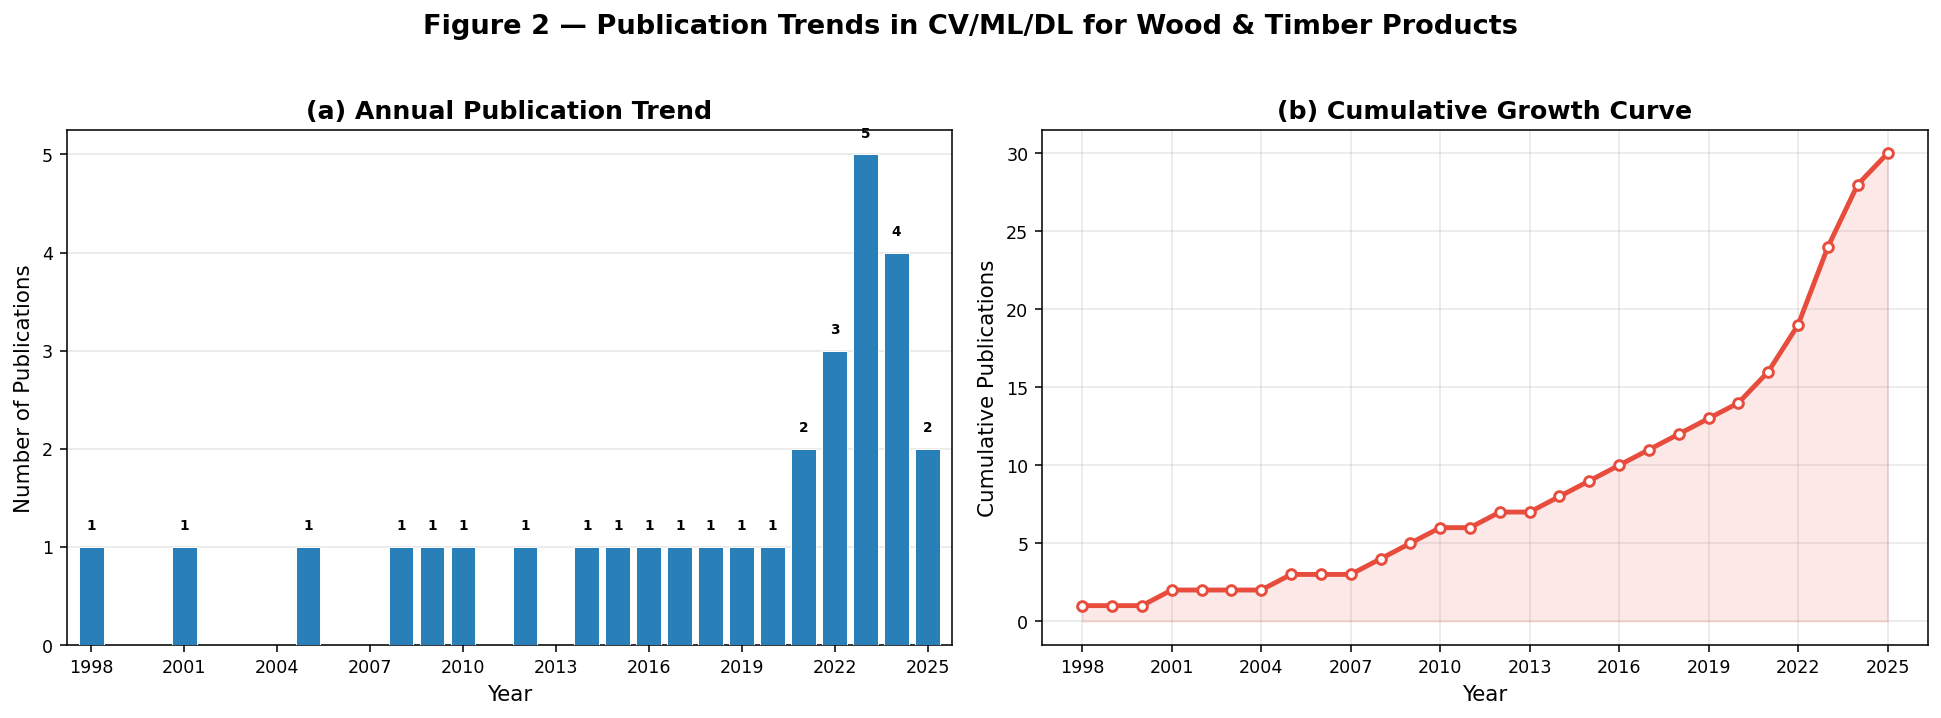

In [9]:
# [CELL 9] — Figure 2a/2b: Publication trend and cumulative growth

year_counts = df["Year"].value_counts().sort_index()
all_years = range(year_counts.index.min(), year_counts.index.max() + 1)
year_counts = year_counts.reindex(all_years, fill_value=0)
cumulative  = year_counts.cumsum()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ── Panel (a): Annual bar chart ──
bars = ax1.bar(
    year_counts.index, year_counts.values,
    color="#2980b9", edgecolor="white", linewidth=0.5,
    zorder=3,
)
# Annotate bars with counts
for bar in bars:
    h = bar.get_height()
    if h > 0:
        ax1.text(
            bar.get_x() + bar.get_width() / 2, h + 0.15,
            str(int(h)), ha="center", va="bottom", fontsize=7, fontweight="bold",
        )
ax1.set_xlabel("Year")
ax1.set_ylabel("Number of Publications")
ax1.set_title("(a) Annual Publication Trend", fontweight="bold")
ax1.grid(axis="y", alpha=0.3, zorder=0)
ax1.set_axisbelow(True)
ax1.xaxis.set_major_locator(mticker.MaxNLocator(integer=True, nbins=12))
ax1.set_xlim(year_counts.index.min() - 0.8, year_counts.index.max() + 0.8)

# ── Panel (b): Cumulative growth ──
ax2.plot(
    cumulative.index, cumulative.values,
    color="#e74c3c", linewidth=2.5, marker="o", markersize=5,
    markerfacecolor="white", markeredgecolor="#e74c3c", markeredgewidth=1.5,
    zorder=3,
)
ax2.fill_between(cumulative.index, cumulative.values, alpha=0.12, color="#e74c3c")
ax2.set_xlabel("Year")
ax2.set_ylabel("Cumulative Publications")
ax2.set_title("(b) Cumulative Growth Curve", fontweight="bold")
ax2.grid(alpha=0.3, zorder=0)
ax2.set_axisbelow(True)
ax2.xaxis.set_major_locator(mticker.MaxNLocator(integer=True, nbins=12))

fig.suptitle(
    "Figure 2 — Publication Trends in CV/ML/DL for Wood & Timber Products",
    fontsize=14, fontweight="bold", y=1.02,
)
plt.tight_layout()
plt.show()

### 6.2 — Figure 9: Application Category Distribution (Horizontal Bar + Donut)

Dual visualization of the distribution of papers across the 9 application categories.

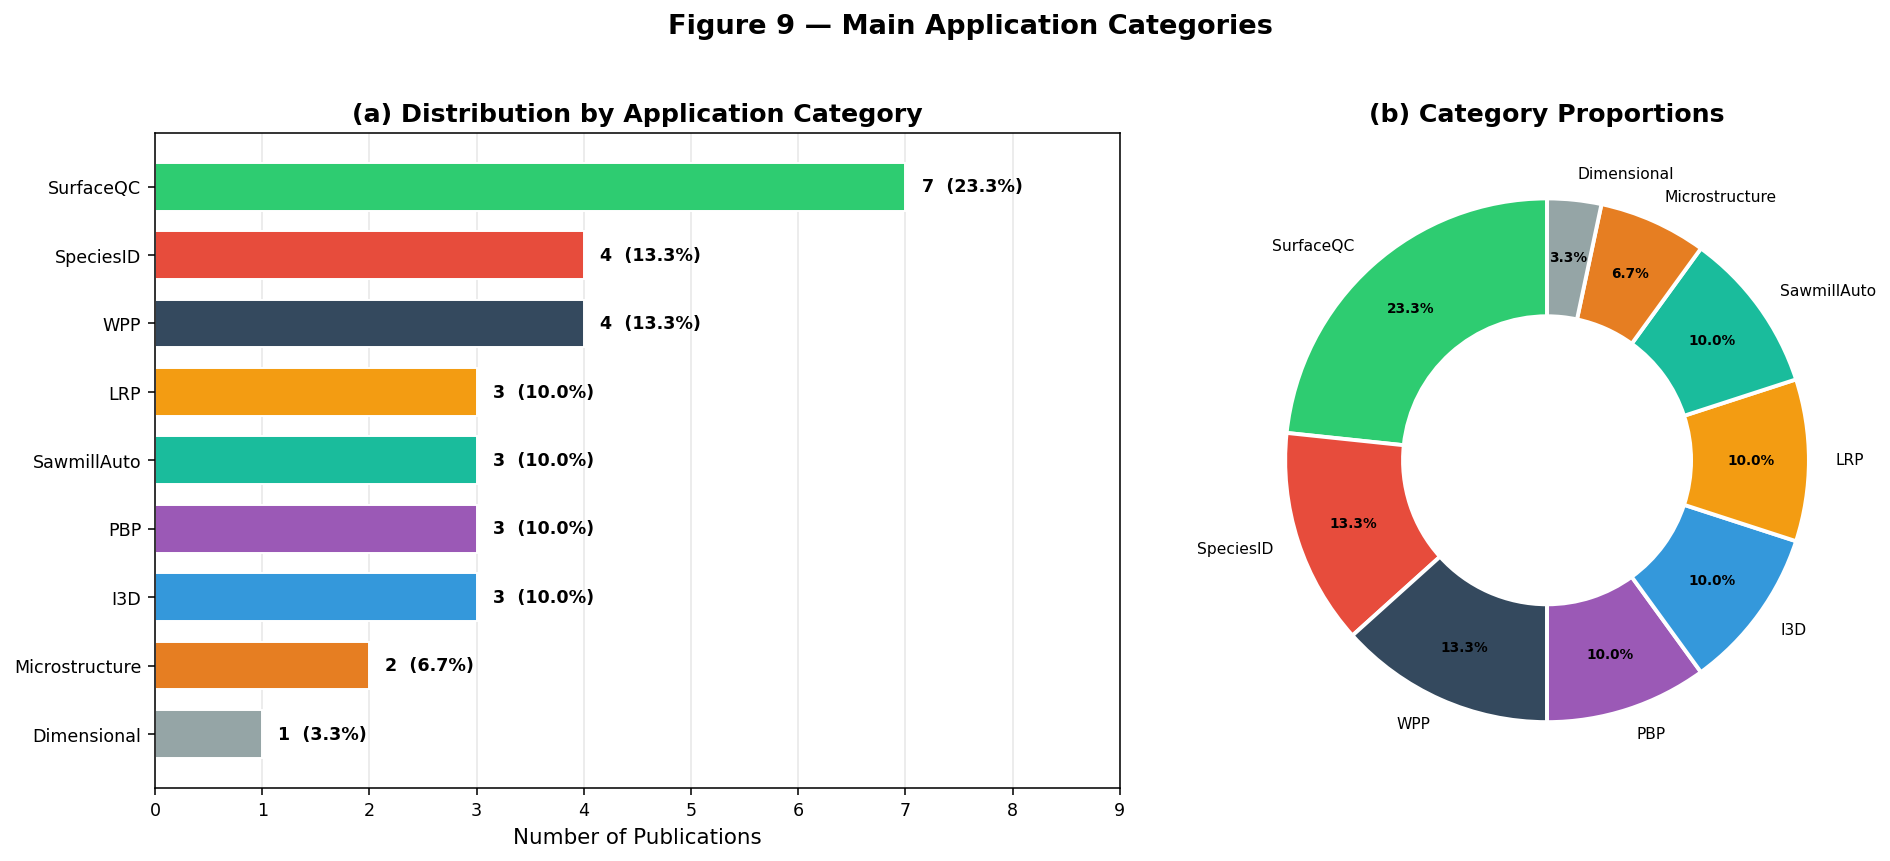

In [10]:
# [CELL 10] — Figure 9: Application category distribution

app_dist = df["Pred_Application"].value_counts().sort_values(ascending=True)
colors = [APP_PALETTE.get(cat, "#bdc3c7") for cat in app_dist.index]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={"width_ratios": [1.3, 1]})

# ── Panel (a): Horizontal bar chart ──
bars = ax1.barh(app_dist.index, app_dist.values, color=colors, edgecolor="white", height=0.7)
for bar, val in zip(bars, app_dist.values):
    ax1.text(
        val + 0.15, bar.get_y() + bar.get_height() / 2,
        f"{val}  ({val / len(df) * 100:.1f}%)",
        va="center", fontsize=9, fontweight="bold",
    )
ax1.set_xlabel("Number of Publications")
ax1.set_title("(a) Distribution by Application Category", fontweight="bold")
ax1.set_xlim(0, app_dist.max() + 2)
ax1.grid(axis="x", alpha=0.3)
ax1.set_axisbelow(True)

# ── Panel (b): Donut chart ──
app_donut = df["Pred_Application"].value_counts().sort_values(ascending=False)
donut_colors = [APP_PALETTE.get(cat, "#bdc3c7") for cat in app_donut.index]

wedges, texts, autotexts = ax2.pie(
    app_donut.values,
    labels=app_donut.index,
    colors=donut_colors,
    autopct="%1.1f%%",
    pctdistance=0.78,
    startangle=90,
    wedgeprops={"width": 0.45, "edgecolor": "white", "linewidth": 2},
    textprops={"fontsize": 8},
)
for t in autotexts:
    t.set_fontsize(7)
    t.set_fontweight("bold")
ax2.set_title("(b) Category Proportions", fontweight="bold")

fig.suptitle(
    "Figure 9 — Main Application Categories",
    fontsize=14, fontweight="bold", y=1.02,
)
plt.tight_layout()
plt.show()

### 6.3 — Figure 10: Heatmap of Method Distribution across Application Categories

Cross-tabulation heatmap showing how Deep Learning, Classical ML, and Classical CV are distributed across each application category.

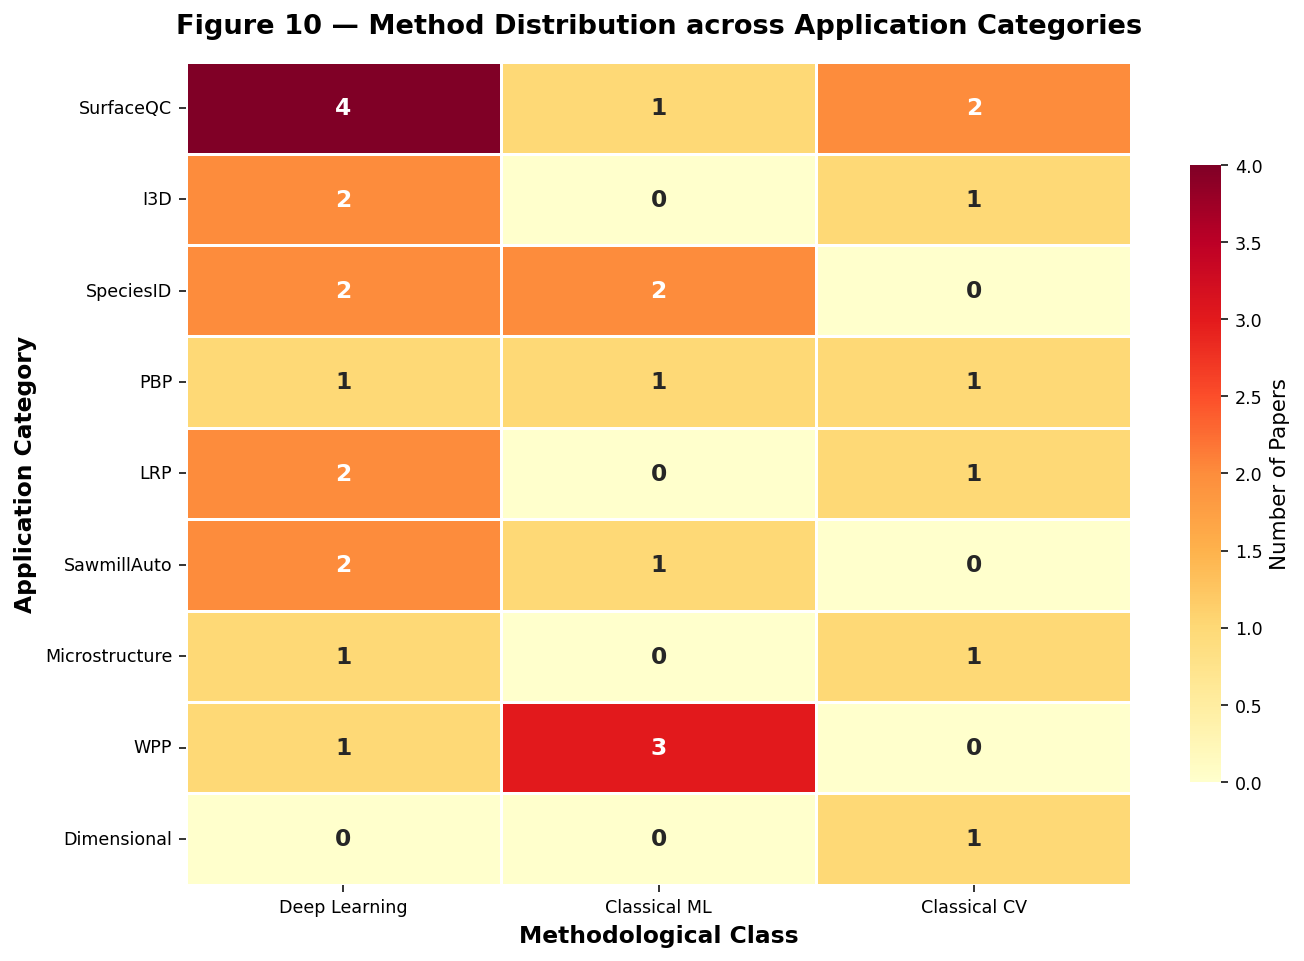

In [11]:
# [CELL 11] — Figure 10: Method × Application heatmap

# Build cross-tabulation
method_order = ["Deep Learning", "Classical ML", "Classical CV"]
app_order    = list(APP_PALETTE.keys())

ct = pd.crosstab(
    df["Pred_Application"], df["Pred_Method"]
).reindex(index=app_order, columns=method_order, fill_value=0)

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(
    ct,
    annot=True,
    fmt="d",
    cmap="YlOrRd",
    linewidths=1.5,
    linecolor="white",
    cbar_kws={"label": "Number of Papers", "shrink": 0.75},
    square=False,
    ax=ax,
    annot_kws={"fontsize": 12, "fontweight": "bold"},
)

ax.set_xlabel("Methodological Class", fontsize=12, fontweight="bold")
ax.set_ylabel("Application Category", fontsize=12, fontweight="bold")
ax.set_title(
    "Figure 10 — Method Distribution across Application Categories",
    fontsize=14, fontweight="bold", pad=15,
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()

### 6.4 — Figures 11b / 12: Evolution of Deep Learning vs. Classical CV over Time

Line chart tracking the proportion of papers using Deep Learning, Classical ML, and Classical CV across time periods, showing the rise of DL in recent years.

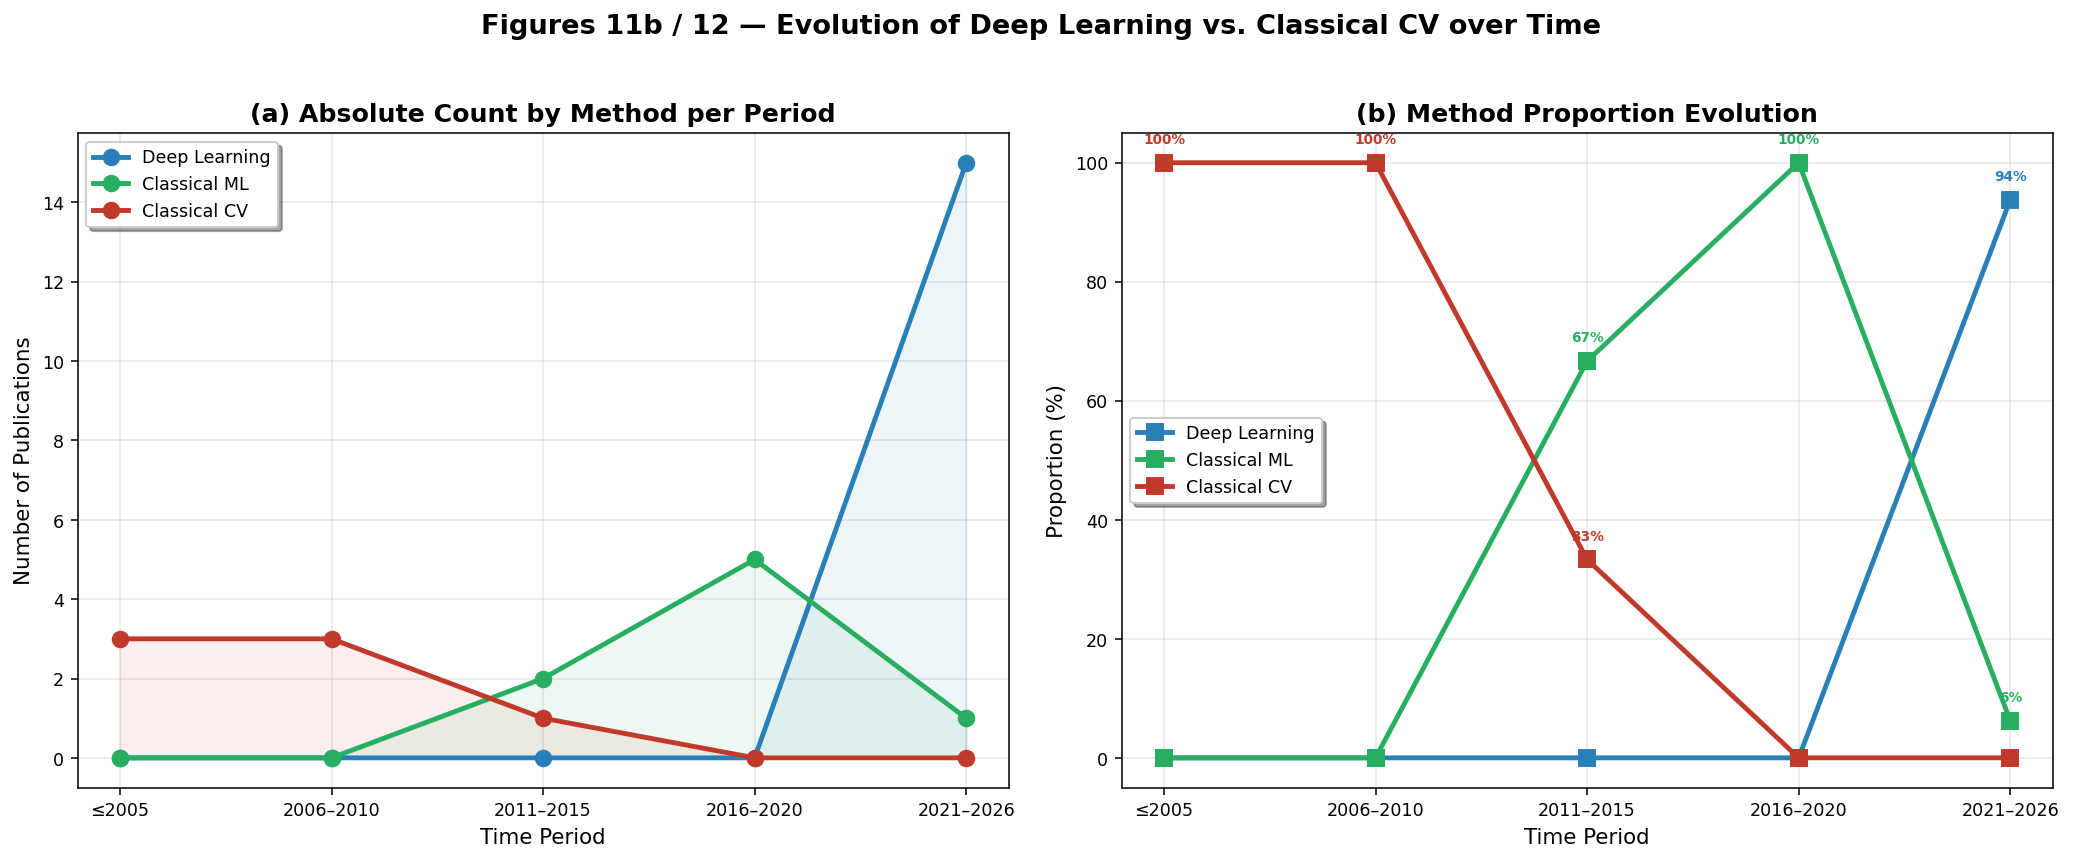

In [12]:
# [CELL 12] — Figure 11b/12: Methodological evolution over time periods

# ── Define time periods ──────────────────────────────────────────────
def assign_period(year: int) -> str:
    """Assign a publication year to a time period bin."""
    if year <= 2005:
        return "≤2005"
    elif year <= 2010:
        return "2006–2010"
    elif year <= 2015:
        return "2011–2015"
    elif year <= 2020:
        return "2016–2020"
    else:
        return "2021–2026"


df["Period"] = df["Year"].apply(assign_period)

period_order = ["≤2005", "2006–2010", "2011–2015", "2016–2020", "2021–2026"]

# Cross-tab: period × method
period_method = pd.crosstab(
    df["Period"], df["Pred_Method"]
).reindex(index=period_order, columns=method_order, fill_value=0)

# Normalize to proportions per period
period_method_pct = period_method.div(period_method.sum(axis=1), axis=0) * 100

# ── Plot ──────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Panel (a): Absolute counts — stacked area
for method in method_order:
    ax1.plot(
        period_method.index, period_method[method],
        marker="o", linewidth=2.5, markersize=8,
        label=method, color=METHOD_PALETTE[method],
        zorder=3,
    )
    ax1.fill_between(
        range(len(period_method.index)), period_method[method].values,
        alpha=0.08, color=METHOD_PALETTE[method],
    )

ax1.set_xlabel("Time Period")
ax1.set_ylabel("Number of Publications")
ax1.set_title("(a) Absolute Count by Method per Period", fontweight="bold")
ax1.legend(frameon=True, fancybox=True, shadow=True)
ax1.grid(alpha=0.3)
ax1.set_axisbelow(True)
ax1.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Panel (b): Proportions (%) — line chart
for method in method_order:
    ax2.plot(
        period_method_pct.index, period_method_pct[method],
        marker="s", linewidth=2.5, markersize=8,
        label=method, color=METHOD_PALETTE[method],
        zorder=3,
    )

ax2.set_xlabel("Time Period")
ax2.set_ylabel("Proportion (%)")
ax2.set_title("(b) Method Proportion Evolution", fontweight="bold")
ax2.set_ylim(-5, 105)
ax2.legend(frameon=True, fancybox=True, shadow=True)
ax2.grid(alpha=0.3)
ax2.set_axisbelow(True)

# Annotate key data points
for method in method_order:
    for i, (period, pct) in enumerate(zip(period_method_pct.index, period_method_pct[method])):
        if pct > 0:
            ax2.annotate(
                f"{pct:.0f}%",
                (i, pct),
                textcoords="offset points", xytext=(0, 10),
                ha="center", fontsize=7, fontweight="bold",
                color=METHOD_PALETTE[method],
            )

fig.suptitle(
    "Figures 11b / 12 — Evolution of Deep Learning vs. Classical CV over Time",
    fontsize=14, fontweight="bold", y=1.02,
)
plt.tight_layout()
plt.show()

---
## 7. Summary Statistics & Export

Final summary of all classification results and optional CSV export.

In [13]:
# [CELL 13] — Summary statistics

print("=" * 70)
print("  FINAL SUMMARY")
print("=" * 70)

print(f"\n  Total records analysed: {len(df)}")
print(f"  Year range:            {df['Year'].min()} – {df['Year'].max()}")
print(f"  Unique countries:      {df['Country'].nunique()}")

print("\n  ── Application Classification ──")
print(f"  Accuracy:      {app_metrics['accuracy']:.4f}")
print(f"  Macro-F1:      {app_metrics['macro_f1']:.4f}")
print(f"  Weighted-F1:   {app_metrics['weighted_f1']:.4f}")

print("\n  ── Methodological Classification ──")
print(f"  Accuracy:      {method_metrics['accuracy']:.4f}")
print(f"  Macro-F1:      {method_metrics['macro_f1']:.4f}")
print(f"  Weighted-F1:   {method_metrics['weighted_f1']:.4f}")

print("\n  ── Application Category Counts ──")
for cat in PRIORITY_ORDER:
    count = (df["Pred_Application"] == cat).sum()
    pct   = count / len(df) * 100
    print(f"    {cat:20s}: {count:3d}  ({pct:5.1f}%)")

print("\n  ── Method Counts ──")
for m in method_order:
    count = (df["Pred_Method"] == m).sum()
    pct   = count / len(df) * 100
    print(f"    {m:20s}: {count:3d}  ({pct:5.1f}%)")

  FINAL SUMMARY

  Total records analysed: 30
  Year range:            1998 – 2025
  Unique countries:      19

  ── Application Classification ──
  Accuracy:      0.9667
  Macro-F1:      0.9407
  Weighted-F1:   0.9644

  ── Methodological Classification ──
  Accuracy:      1.0000
  Macro-F1:      1.0000
  Weighted-F1:   1.0000

  ── Application Category Counts ──
    WPP                 :   4  ( 13.3%)
    LRP                 :   3  ( 10.0%)
    PBP                 :   3  ( 10.0%)
    SurfaceQC           :   7  ( 23.3%)
    SpeciesID           :   4  ( 13.3%)
    SawmillAuto         :   3  ( 10.0%)
    Microstructure      :   2  (  6.7%)
    Dimensional         :   1  (  3.3%)
    I3D                 :   3  ( 10.0%)

  ── Method Counts ──
    Deep Learning       :  15  ( 50.0%)
    Classical ML        :   8  ( 26.7%)
    Classical CV        :   7  ( 23.3%)


In [14]:
# [CELL 14] — Export results to CSV

export_cols = [
    "Title", "Year", "Country", "Document Type", "Citations",
    "GT_Application", "Pred_Application",
    "GT_Method", "Pred_Method",
]

output_path = "wood_timber_classification_results.csv"
df[export_cols].to_csv(output_path, index=False, encoding="utf-8-sig")
print(f"\n✅ Results exported to: {output_path}")
print("   Download from the Colab file browser (📁 icon on the left).")


✅ Results exported to: wood_timber_classification_results.csv
   Download from the Colab file browser (📁 icon on the left).


---
## 8. Appendix: Confusion Matrices (Visual)

Heatmap visualizations of the confusion matrices for both classifiers.

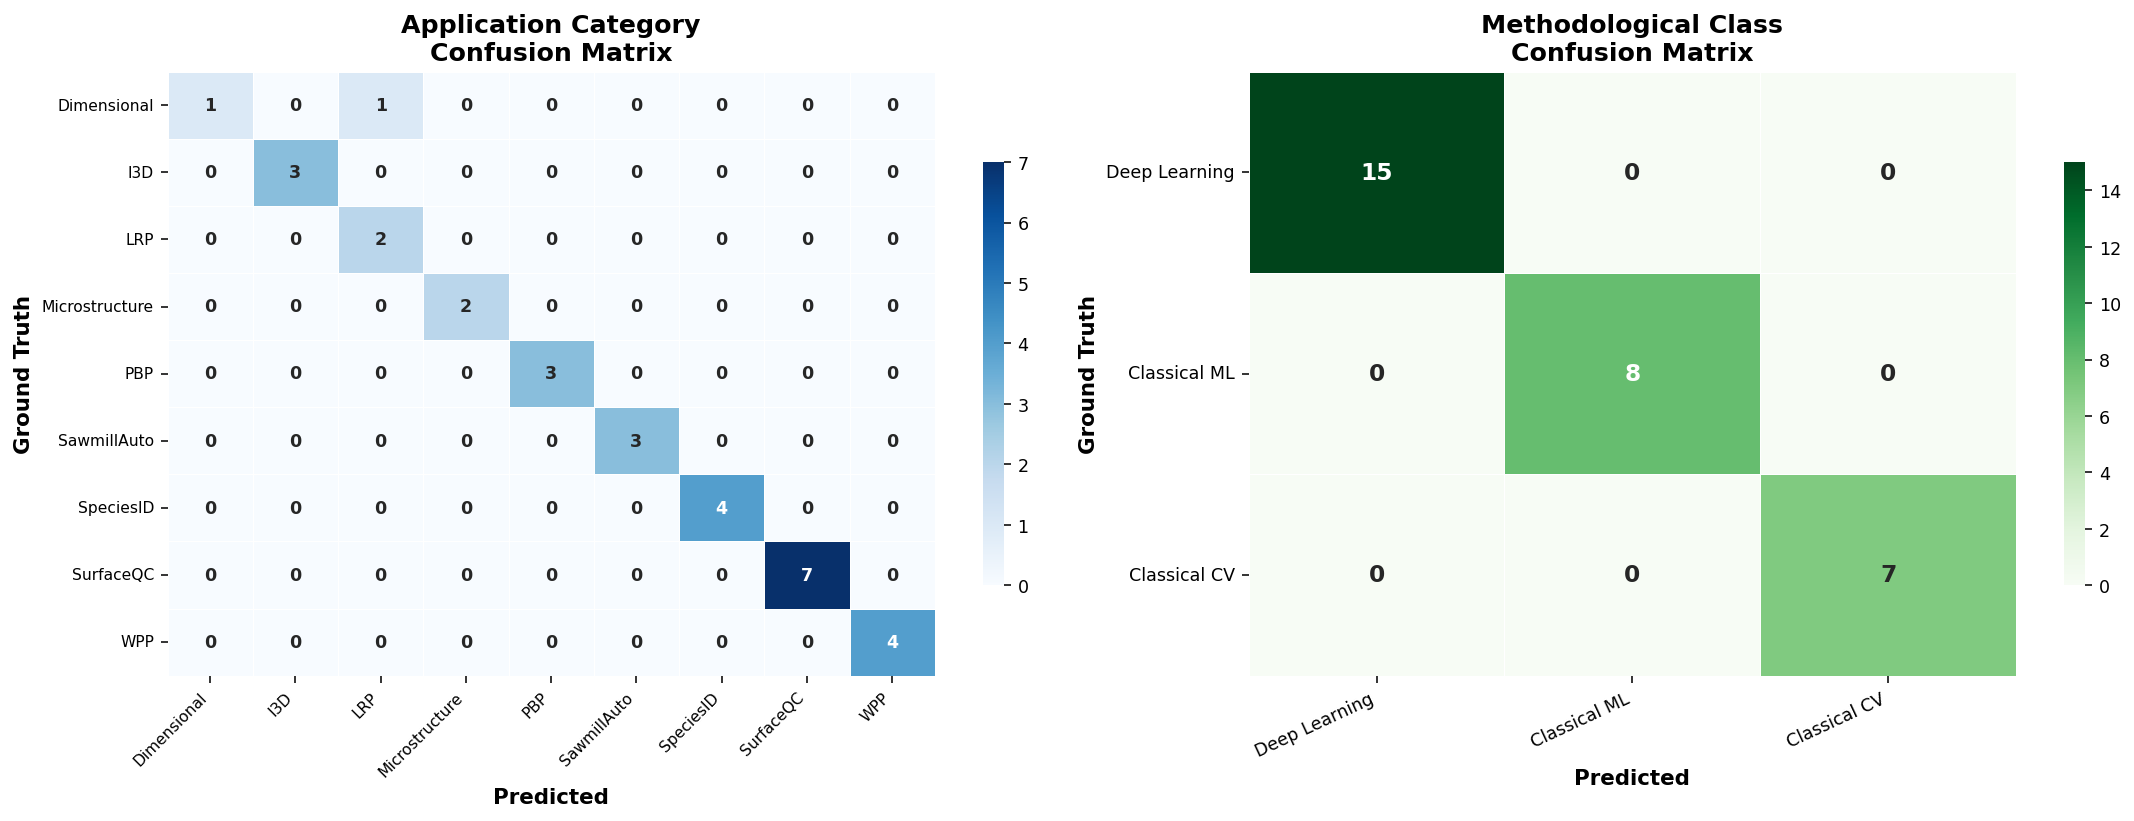

In [15]:
# [CELL 15] — Confusion matrices (heatmaps)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ── Application Confusion Matrix ──
app_labels = sorted(df["GT_Application"].unique())
cm_app = confusion_matrix(df["GT_Application"], df["Pred_Application"], labels=app_labels)
sns.heatmap(
    cm_app, annot=True, fmt="d", cmap="Blues",
    xticklabels=app_labels, yticklabels=app_labels,
    linewidths=0.5, linecolor="white", ax=ax1,
    cbar_kws={"shrink": 0.7},
    annot_kws={"fontsize": 9, "fontweight": "bold"},
)
ax1.set_xlabel("Predicted", fontweight="bold")
ax1.set_ylabel("Ground Truth", fontweight="bold")
ax1.set_title("Application Category\nConfusion Matrix", fontweight="bold")
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha="right", fontsize=8)
ax1.set_yticklabels(ax1.get_yticklabels(), rotation=0, fontsize=8)

# ── Method Confusion Matrix ──
cm_method = confusion_matrix(df["GT_Method"], df["Pred_Method"], labels=method_order)
sns.heatmap(
    cm_method, annot=True, fmt="d", cmap="Greens",
    xticklabels=method_order, yticklabels=method_order,
    linewidths=0.5, linecolor="white", ax=ax2,
    cbar_kws={"shrink": 0.7},
    annot_kws={"fontsize": 12, "fontweight": "bold"},
)
ax2.set_xlabel("Predicted", fontweight="bold")
ax2.set_ylabel("Ground Truth", fontweight="bold")
ax2.set_title("Methodological Class\nConfusion Matrix", fontweight="bold")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=25, ha="right", fontsize=9)
ax2.set_yticklabels(ax2.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.show()

---
## 9. Using Your Own Scopus Data

To apply this pipeline to **real Scopus export data**, replace Cell 3 with:

```python
# Upload your Scopus CSV export to Colab, then:
from google.colab import files
uploaded = files.upload()  # interactive file upload

filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

# Rename columns to match expected names if needed:
column_mapping = {
    'Title': 'Title',
    'Abstract': 'Abstract',
    'Author Keywords': 'Author Keywords',
    'Index Keywords': 'Index Keywords',
    'Year': 'Year',
    'Cited by': 'Citations',
    'Document Type': 'Document Type',
    'Authors with affiliations': 'Country',  # or extract from Affiliations
}
df = df.rename(columns=column_mapping)
```

> **Note**: When using real data, the `GT_Application` and `GT_Method` columns will not exist. You can manually label a subset for validation, or use the predicted columns directly for analysis.

---

**Notebook created following the methodology of:**  
Goycochea Casas et al. (2026). *Computer Vision, Machine Learning, and Deep Learning for Wood and Timber Products: A Scopus-Based Bibliometric and Systematic Mapping Review (1983–2026, Early Access)*. Forests.

---